# Latent Style Approach
This notebook shows how to load the trained latent-style model and use it for inference. The model works together with two fixed pretrained components: a MUNIT generator, which encodes and decodes images through content and style representations, and an emotion regressor, which was used during training to guide the style transformation.

The notebook first loads all required model components, including the generator configuration and checkpoint, the pretrained emotion regressor, and the trained latent-style checkpoint. It then prepares the input image, encodes it into the MUNIT latent space, applies the learned style-space transformation with a chosen alpha value, and decodes the result back into an image.

The goal is to demonstrate how a trained latent direction model can be used after training to generate transformed images without updating any model weights.

## Setup imports and device check

This cell imports the libraries and project modules needed for inference. It loads PyTorch, MLflow, plotting utilities, image transforms, the MUNIT generator components, the COCO dataset helper, the pretrained emotion regressor, and the trained latent-style model class.

It also configures notebook plots to use SVG output, selects CUDA as the target device, and prints basic GPU information. This makes it clear which hardware the inference notebook is running on before any model checkpoints are loaded.

In [1]:
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
import matplotlib.pyplot as plt

from social_media_overlay.ext.imaginaire.config import Config
from social_media_overlay.ext.imaginaire.generators.munit import Generator
from social_media_overlay.ext.gebhardt.utils import get_relevant_states

from torch.utils.data import DataLoader
from social_media_overlay.ext.gebhardt.dataset.CocoCaptions import CocoCaptions

from social_media_overlay.models.regressor import EmotionRegressor

from social_media_overlay.utils import get_first_n_images
from social_media_overlay.ext.gebhardt.utils import denorm

%config InlineBackend.figure_format = 'svg'
device = torch.device('cuda')

print("Device Info")
print("Selected device:", device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU count:", torch.cuda.device_count())
    print("Current GPU index:", torch.cuda.current_device())
    print("GPU name:", torch.cuda.get_device_name(torch.cuda.current_device()))
    print("GPU capability:", torch.cuda.get_device_capability())
else:
    print("Running on CPU")

Device Info
Selected device: cuda
CUDA available: True
CUDA version: 12.6
GPU count: 8
Current GPU index: 0
GPU name: Tesla P100-SXM2-16GB
GPU capability: (6, 0)


## Load and inspect the validation dataset

This cell defines the preprocessing pipeline for the COCO validation images and creates a DataLoader for inference. The images are resized, center-cropped, converted to tensors, and normalized to the `[-1, 1]` range expected by the pretrained generator and regressor.

The dataset is loaded without shuffling so that inference results stay reproducible and easy to compare across runs. The cell then prints basic dataset and DataLoader information, such as the number of samples, batch size, worker count, and number of batches, before displaying the first dataset item as a quick sanity check.

In [2]:
dataset_input_size = 480  # 1024
dataset_crop_size = 448  # 1024
dataset_batch_size = 2
dataset_shuffle = False


data_transforms = transforms.Compose([
    transforms.Resize(dataset_input_size),
    transforms.CenterCrop(dataset_crop_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # this will be [-1,1]
])

dataset_coco = CocoCaptions("../data/coco", "val", data_transforms)
data_loader = DataLoader(
    dataset_coco,
    batch_size=dataset_batch_size,
    shuffle=dataset_shuffle,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Dataset length:", len(dataset_coco))
print("Batch size:", data_loader.batch_size)
print("Shuffle:", dataset_shuffle)
print("Num workers:", data_loader.num_workers)
print("Number of batches per epoch:", len(data_loader))

dataset_coco[0]

Dataset length: 5000
Batch size: 2
Shuffle: False
Num workers: 4
Number of batches per epoch: 2500


(tensor([[[-0.1765, -0.1765, -0.2000,  ...,  0.3412,  0.7176,  0.9216],
          [-0.1451, -0.1451, -0.1765,  ...,  0.1059,  0.4667,  0.7725],
          [-0.1137, -0.1137, -0.1216,  ..., -0.0275,  0.1922,  0.6941],
          ...,
          [-0.2157, -0.2157, -0.3020,  ...,  0.0431,  0.0667,  0.0588],
          [-0.2235, -0.1608, -0.4039,  ..., -0.0353, -0.0980,  0.0353],
          [-0.2392, -0.1216, -0.2627,  ..., -0.2314, -0.1922, -0.0275]],
 
         [[-0.0431, -0.0431, -0.0667,  ...,  0.3882,  0.7490,  0.9529],
          [-0.0353, -0.0353, -0.0431,  ...,  0.1529,  0.4980,  0.8039],
          [-0.0039, -0.0039, -0.0118,  ...,  0.0196,  0.2314,  0.7098],
          ...,
          [-0.1686, -0.1843, -0.2941,  ...,  0.0275,  0.0510,  0.0431],
          [-0.1922, -0.1451, -0.4039,  ..., -0.0510, -0.1137,  0.0196],
          [-0.2235, -0.1137, -0.2627,  ..., -0.2471, -0.2078, -0.0431]],
 
         [[ 0.0118,  0.0118, -0.0039,  ...,  0.3725,  0.7569,  0.9765],
          [ 0.0353,  0.0353,

## Load the pretrained MUNIT generator

This cell loads the pretrained MUNIT generator from the Imaginaire configuration and checkpoint. The generator is moved to the selected device and its parameters are frozen, since it is only used as a fixed encoder and decoder during inference.

The cell then runs two small test inputs through `autoencoder_a`. First, it checks that an image can be encoded into content and style representations and decoded again. Then, it repeats the same process with a smaller dummy input to inspect the MUNIT latent-space shapes. The extracted `style_dim` is used later when creating the latent-style model.

In [3]:
cfg = Config("../src/social_media_overlay/ext/imaginaire/imagenet2imagenet.yaml")
gen = Generator(cfg.gen, cfg.data)

state_dict = torch.load("../data/gebhardt/models/imaginaire_munit_200000_s5.pt")

gen_sate_dict = get_relevant_states(state_dict['net_G'])
gen.load_state_dict(gen_sate_dict)
gen = gen.to(device)

for p in gen.parameters():
    p.requires_grad = False

# Example input
x = torch.randn(1, 3, 1024, 1024, device=device)

with torch.no_grad():
    content_a, style_a = gen.autoencoder_a.encode(x)
    out = gen.autoencoder_a.decode(content_a, style_a)

print("content shape:", tuple(content_a.shape))
print("style shape:", tuple(style_a.shape))
print("decoder A output shape:", tuple(out.shape))



# dummy input
gen.eval()
x = torch.randn(1, 3, 256, 256).to(device)

with torch.no_grad():
    content_a, style_a = gen.autoencoder_a.encode(x)
    out = gen.autoencoder_a.decode(content_a, style_a)

print("MUNIT Latent Space Info")
print("Content shape:", content_a.shape)
print("Style shape:", style_a.shape)

# extract style dimension
style_dim = style_a.shape[1]
print("Style dimension:", style_dim)
print("decoder A output shape:", tuple(out.shape))

content shape: (1, 256, 128, 128)
style shape: (1, 8, 1, 1)
decoder A output shape: (1, 3, 1024, 1024)
MUNIT Latent Space Info
Content shape: torch.Size([1, 256, 32, 32])
Style shape: torch.Size([1, 8, 1, 1])
Style dimension: 8
decoder A output shape: (1, 3, 256, 256)


## Load the pretrained emotion regressor

This cell loads the pretrained valence-arousal emotion regressor used to score generated images. The regressor is moved to the selected device and kept fixed, because inference should only use it as an evaluator and not update its weights.

The model is loaded with crop averaging enabled and normalization disabled, matching the setup used in the training scripts. Freezing the regressor parameters also makes the inference setup consistent with training, where the regressor provides a stable emotional signal for the latent-style transformation.

In [4]:
path_to_regressor_model = "../data/gebhardt/models/va_pred_all"
regressor = EmotionRegressor(
    path_to_regressor_model,
    average=True,
    normalize=False
)
regressor.to(device)

for p in regressor.model.parameters():
    p.requires_grad = False

## Load a trained latent-style checkpoint

This cell loads a saved training checkpoint and restores the trained latent-style model for inference. The checkpoint contains the trained model weights and the recorded training loss history.

The example below uses `LatentStyleModel`, which learns one global direction in the MUNIT style space. If the checkpoint was trained with the dense version instead, replace it with `LatentStyleDenseModel` and pass the same fixed `regressor`, fixed `generator`, `style_dim`, and alpha range. The important point is that the class used here must match the class that was used when the checkpoint was trained.

After the model weights are loaded, the cell extracts the saved loss history, prints how many loss values were stored, and plots the training loss curve. This is useful as a quick check that the correct checkpoint was loaded and that the training run behaved as expected.

Loaded 3125 loss values


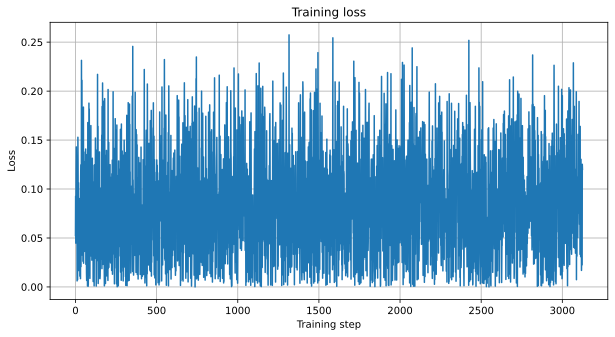

In [7]:
from social_media_overlay.models.latent_style import LatentStyleModel

# Directory that contains the checkpoint from the finished training run.
model_directory = "../data/models/latent-style/checkpoints-ganalyze-normal-lrsm/"

# Path to the final checkpoint file.
# This checkpoint must match the model class used below.
saved_path = model_directory + "checkpoints-ganalyze-normal-lrsm-b2-ddp-final.pt"

checkpoint = torch.load(saved_path)

# Choose the model class that matches the checkpoint:
#
# Use LatentStyleModel if the checkpoint was trained with the global-direction model.
# This model learns one shared direction in style space and applies it to all images.
#
# Use LatentStyleDenseModel if the checkpoint was trained with the dense model.
# This model predicts a separate style-space direction for each input image.
#
# Example dense version:
#
# model = LatentStyleDenseModel(
#     regressor=regressor,
#     generator=gen,
#     style_dim=style_dim,
#     a_min=-0.5,
#     a_max=0.0,
#     direction_depth=3,
# ).to(device)

model = LatentStyleModel(
    regressor=regressor,
    generator=gen,
    style_dim=style_dim,
    a_min=-0.5,
    a_max=0.0,
).to(device)

# Restore the trained parameters from the checkpoint.
# The key "model_state_dict" is used by the training scripts when saving checkpoints.
model.load_state_dict(checkpoint["model_state_dict"])

# Switch to evaluation mode for inference.
# The generator and regressor are already frozen, but eval mode makes the setup explicit.
model.eval()

# Load the saved training loss values for inspection.
loss_history = checkpoint["loss_history"]

print(f"Loaded {len(loss_history)} loss values")

# Plot the training loss curve as a quick check of the training run.
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training loss")
plt.grid(True)
plt.savefig(model_directory + "train_loss.svg")
plt.show()

## Generate transformed images for different alpha values

This cell runs inference on a small batch of validation images and shows how the trained latent-style model changes the output image as the alpha value is varied. The selected alpha values control the strength of the learned style-space transformation. An alpha of `0.0` acts as the identity reference, while more negative values push the image further along the learned direction.

First, the code takes the first 8 images from the DataLoader and moves them to the GPU. The model, generator, and regressor are then switched to evaluation mode. For each alpha value, the code creates a batch-shaped alpha tensor, generates transformed images with `generate_transformed_images`, and stores both the outputs and the regressor predictions.

The cell also computes the original regressor scores for the unmodified input images. These scores contain valence and arousal values. After that, the images are visualized in a grid. The first column shows the original images and their predicted valence/arousal scores. The remaining columns show the transformed outputs for each alpha value, together with the predicted valence and arousal as well as the differences relative to the identity case (`alpha = 0.0`).

This makes it easy to inspect whether the learned latent direction changes the images in the intended way and how strongly the emotional predictions shift as alpha becomes larger in magnitude.

In [8]:
# Alpha values used for image transformation.
# 0.0 should be included, because it is used as the identity reference.
ALPHAS = [0.0, -0.1, -0.25, -0.5]

# Number of images to take from the dataloader for visualization.
NUM_IMAGES = 8

# Output file name for the saved figure.
OUTPUT_FILENAME = "samples_neg_448.svg"

# Figure layout settings.
FIGURE_WIDTH_PER_COLUMN = 3.8
FIGURE_HEIGHT_PER_ROW = 3.6
TITLE_FONT_SIZE = 10


X = get_first_n_images(data_loader, n=NUM_IMAGES)
X_device = X.to(device)

if 0.0 not in ALPHAS:
    raise ValueError("ALPHAS must contain 0.0 so an identity reference can be computed.")

model.eval()
model.regressor.eval()
model.generator.eval()

outputs = []
scores_list = []

with torch.no_grad():
    # Scores for the original, unmodified input images.
    original_scores = model.regressor.predict(X_device).detach().cpu()

    for alpha in ALPHAS:
        alpha_tensor = torch.full(
            (X_device.size(0), 1),
            alpha,
            device=device,
        )

        transformed_images = model.generate_transformed_images(
            X=X_device,
            alphas=alpha_tensor,
        )
        outputs.append(transformed_images.detach().cpu())

        transformed_scores = model.regressor.predict(transformed_images).detach().cpu()
        scores_list.append(transformed_scores)

# Use alpha = 0.0 as the identity reference for score differences.
identity_idx = ALPHAS.index(0.0)
identity_scores = scores_list[identity_idx]

rows = X.size(0)
cols = len(ALPHAS) + 1

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(FIGURE_WIDTH_PER_COLUMN * cols, FIGURE_HEIGHT_PER_ROW * rows),
)

if rows == 1:
    axes = axes[None, :]

for r in range(rows):
    ax = axes[r, 0]
    original_img = denorm(X[r]).permute(1, 2, 0).cpu().numpy()

    v_orig = original_scores[r, 0].item()
    a_orig = original_scores[r, 1].item()

    ax.imshow(original_img)
    ax.set_title(
        f"original\nv={v_orig:.3f}, a={a_orig:.3f}\n",
        fontsize=TITLE_FONT_SIZE,
    )
    ax.axis("off")

    for c, alpha in enumerate(ALPHAS, start=1):
        ax = axes[r, c]
        transformed_img = denorm(outputs[c - 1][r]).permute(1, 2, 0).cpu().numpy()

        v = scores_list[c - 1][r, 0].item()
        a = scores_list[c - 1][r, 1].item()

        v_identity = identity_scores[r, 0].item()
        a_identity = identity_scores[r, 1].item()

        dv = v - v_identity
        da = a - a_identity

        label = "identity" if alpha == 0.0 else f"α={alpha}"

        ax.imshow(transformed_img)
        ax.set_title(
            f"{label}\nv={v:.3f}, a={a:.3f}\nΔv={dv:+.3f}, Δa={da:+.3f}",
            fontsize=TITLE_FONT_SIZE,
        )
        ax.axis("off")

plt.tight_layout()
plt.savefig(model_directory + OUTPUT_FILENAME)
plt.show()